## Figures 4a, 4b, 4c, 4d — QHO dispersion and Bloch waves

This notebook reproduces **Figures 4a, 4b, and 4c** of the paper.

The periodic medium uses a piecewise-parabolic Helmholtz coefficient
$$F(x) = (C_0 + C_1) - 2C_1\!\left(\frac{\pi}{\lambda}\right)^{\!2}\!\left(x - \frac{\lambda}{2}\right)^2$$
so that the Bloch eigenvalue problem becomes a **quantum harmonic oscillator** (QHO).
The dispersion law then reads $\omega_n = (n + \tfrac{1}{2})\,\omega_0$ with
$\omega_0 = \frac{2\pi}{\lambda}\sqrt{\frac{2C_1}{C_0+C_1}}$.


In [1]:
import numpy as np
import itertools
import scipy.special as sp
from scipy.sparse import diags
from scipy.optimize import fsolve
from scipy.sparse.linalg import eigs
from scipy.linalg import eigh
from scipy.special import mathieu_a, mathieu_cem, mathieu_b, mathieu_sem
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.stats import linregress
from numpy import linalg as LA
import scipy.linalg
import cmath as cm
import matplotlib.pyplot as plt

In [2]:
def find(element, vector):
    
    """ Function returning index of an element in a vector """
    
    for i in range(len(vector)):
        if vector[i] == element:
            return (i)

In [3]:
from scipy.signal import find_peaks

def find_fft_peaks(fft_wave_shifted, k, height=None, distance=None):
    """
    Find the peaks of the FFT and their corresponding wavenumbers.
    
    Parameters:
    - fft_wave_shifted (np.ndarray): The shifted FFT amplitude array.
    - k (np.ndarray): The wavenumbers corresponding to the FFT.
    - height (float, optional): Minimum amplitude for a peak. Default is None.
    - distance (int, optional): Minimum distance between peaks in indices. Default is None.
    
    Returns:
    - peak_k (np.ndarray): Wavenumbers corresponding to the peaks.
    - peak_amplitudes (np.ndarray): Amplitudes of the peaks.
    """
    # Find peaks in the FFT amplitude
    peaks, _ = find_peaks(np.abs(fft_wave_shifted), height=height, distance=distance)
    
    # Extract wavenumbers and amplitudes at the peaks
    peak_k = k[peaks]
    peak_amplitudes = np.abs(fft_wave_shifted[peaks])
    
    # Return unique peaks sorted by wavenumber
    unique_indices = np.argsort(peak_k)
    return peak_k[unique_indices], peak_amplitudes[unique_indices]

In [4]:
def compute_energy(fft_wave, k,NN):
    eps0 = 8.854e-12
    # Compute the squared amplitude of the FFT (energy density in Fourier space)
    amplitude_squared = np.abs(fft_wave)**2
    
    # Compute the spacing in k-space (assumes uniform sampling in k)
    dk = np.abs(k[1] - k[0])  # Assumes k is sorted and evenly spaced
    
    # Integrate energy density over all wavenumbers
    total_energy = eps0*np.sum(amplitude_squared) * (dk)
    
    return total_energy

In [5]:
def compute_floquet_multipliers(AA, qtest):
    
    y_1 = [1., 0.0]
    y_2 = [0.0, 1.]
   
    # The resolution of the ODE needs to be very accurate DOP853 and Radau seem to do a good job
    sol1 = solve_ivp(equation_lin_HQO, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                    t_eval=None,args=(AA, qtest))
    sol2 = solve_ivp(equation_lin_HQO, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                    t_eval=None,args=(AA, qtest))
    # Assembly of the monodromy matrix Phi
    mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , 
                         [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
    eigenValues, _ = scipy.linalg.eig(mat_phi)
    rho1      = eigenValues[0]
    rho2       = eigenValues[1]
    #print(rho1,rho2)
    # Replace log(0) issue with large negative value (-∞)
    solouf = np.array([
        cm.log(ev) / np.pi if not np.isclose(ev, 0) else -np.inf
        for ev in eigenValues
    ], dtype=complex)
    solfinal = solouf[np.argsort(solouf.real)] 
            
    return solfinal


In [6]:
def equation_lin_HQO(t, y, ala, qlq):  
    qq, pp  = y
    dydt = [pp, -(ala+2*qlq-4*qlq*(t-np.pi/2)**2)*qq]
    return dydt


def equation_lin_HQO_time(t, y, xi, epsofxi):
    epsxi = np.interp(t, xi, epsofxi)   
    qq, pp  = y
    dydt = [pp, -1*epsxi*qq]
    return dydt


In [7]:
def sol_comp_mode_floquet(t, y, ala, qlq, sn):
    JJ = np.array([ [0.,1 ],
                       [-(ala+2*qlq-4*qlq*(t-np.pi/2)**2),0.] ],dtype=complex)
    Is = np.array([ [sn,0.],
                       [0.,sn] ],dtype=complex)
    mat_B   = JJ - Is 
    dydt    = np.dot(mat_B,y)
    return dydt



In [8]:
def equation_solve(q, nn, pent):
    """Defines the modified Mathieu equation with s0 and s1 as parameters."""
    return (nn+0.5)*4*np.sqrt(q)-2*q - (2 * q / pent)

def solve_HQO(nn, pent, initial_guesses,xtol=1e-18, maxfev=10000,factor=0.2):
    """Finds solutions for the Mathieu equation with given s0 and s1."""
    solution = []
    for guess in initial_guesses:
        sol = fsolve(equation_solve, guess, args=(nn, pent), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
        if not any(np.isclose(sol, solution, atol=1e-15)):  # Avoid duplicate roots
            solution.append(sol)    
    return solution


### QHO bound states — → Figure 4d

Diagonalizes the Transmon/QHO Schrödinger equation and computes the
Hermite-polynomial eigenstates at $q = E_J/(8E_C) = 20$.
Produces `QHO_bound_states.png`.


[-31.31339741 -14.49111706   1.16052624  15.49304153  28.46304799]


/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_70450/21675159.py:41: ComplexWarning: Casting complex values to real discards the imaginary part
  eigenvectors[inc,:] = p_monic(chi)*np.exp(-np.sqrt(qtest)*(phi/2)**2)*((2*np.sqrt(qtest)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))


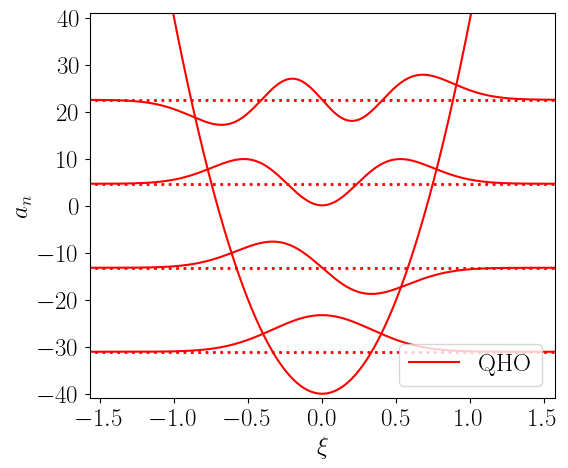

In [9]:
qtest = 20
phi_max = np.pi  # Range for φ
num_points = 2000
phi = np.linspace(-phi_max, phi_max, num_points)

#Laplacy = calculate_laplace_three_point(phi)
#Potent = diags(qtest*phi**2)
#energies, states = eigs((-Laplacy+Potent),k=4, which='SR')

E_C = 1.0  # Charging energy
E_J = 2*qtest*E_C  # Josephson energy
dphi = phi[1] - phi[0]

# Potential term: V(phi) = -E_J * cos(phi)
V = -E_J * np.cos(phi)

# Kinetic term: T = -4 * E_C * d^2/dphi^2
kinetic = -4 * E_C / dphi**2
diagonal_kinetic = np.full(num_points, -2 * kinetic)
off_diagonal_kinetic = np.full(num_points - 1, kinetic)
T = diags([diagonal_kinetic, off_diagonal_kinetic, off_diagonal_kinetic], [0, -1, 1])

# Full Hamiltonian: H = T + V
H = T + diags([V], [0])

# Solve for eigenvalues and eigenvectors
eigenval, eigenvec = eigh(H.toarray())
eigenval = eigenval[:5]  # Only take the first 10 eigenvalues
eigenvec = eigenvec[:, :5]
print(eigenval)

nlist = np.linspace(0,3,4)
energiesana = (0.5+nlist)*4*np.sqrt(qtest)
eigenvectors = np.zeros((nlist.size,phi.size))

chi = np.sqrt(2)*(qtest)**0.25*(phi/2)
inc = -1
for nn in nlist:
    inc = inc + 1
    p_monic = sp.hermite(nn.astype(int), monic=True)
    eigenvectors[inc,:] = p_monic(chi)*np.exp(-np.sqrt(qtest)*(phi/2)**2)*((2*np.sqrt(qtest)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))

Amp0 = 6
Amp1 = 10
Amp2 = 20
Amp3 = 42

fonty = 18
fig7 = plt.figure(7, figsize=(6, 5))
plt.rc('text', usetex=True)

#plt.plot(phi/2, eigenvec[:, 0]*148 + eigenval[0]+0.25,'g-')
#plt.plot(phi/2, eigenvec[:, 1]*104 + eigenval[1]+1.25,'g-')

#plt.plot(xxquantum, energiesana[0]+Amp*states[:, 0].real, label='$\psi_0$')
plt.plot(phi/2, -2*qtest+energiesana[0]+Amp0*eigenvectors[0,:].real,'r-')
plt.plot(phi/2, -2*qtest+energiesana[1]-Amp1*eigenvectors[1,:].real,'r-')
plt.plot(phi/2, -2*qtest+energiesana[2]+Amp2*eigenvectors[2,:].real,'r-')
plt.plot(phi/2, -2*qtest+energiesana[3]+Amp3*eigenvectors[3,:].real,'r-')

plt.plot(np.array([phi[0],phi[-1]]), np.array([1.,1.])*(-2*qtest+energiesana[0]),'r:',linewidth=2)
plt.plot(np.array([phi[0],phi[-1]]), np.array([1.,1.])*(-2*qtest+energiesana[1]),'r:',linewidth=2)
plt.plot(np.array([phi[0],phi[-1]]), np.array([1.,1.])*(-2*qtest+energiesana[2]),'r:',linewidth=2)
plt.plot(np.array([phi[0],phi[-1]]), np.array([1.,1.])*(-2*qtest+energiesana[3]),'r:',linewidth=2)

plt.plot(phi/2, 4*qtest*(phi/2)**2-2*qtest,'r-',markersize=3.,label=r'$\mathrm{QHO}$')
#plt.plot(phi/2, -2*qtest * np.cos(phi),'g-',linewidth=2)

plt.xlabel(r'$\xi$', fontsize=fonty)
plt.ylabel('$a_n$', fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
legend = plt.legend(fontsize=fonty,loc='lower right')
plt.xlim(-phi_max/2, phi_max/2)
#plt.ylim(-1-2*qtest, 4*qtest*(np.pi/2)**2-2*qtest)
plt.ylim(-1-2*qtest, 40+1)
fig7 = plt.gcf()
plt.show()

fig7.savefig('QHO_bound_states.png', format='png', dpi=1000,bbox_inches='tight')


### Floquet stability map for the QHO medium (saves `Map_rho_HQO.npy`)

Scans the $(a, q)$ Mathieu parameter plane with the piecewise-parabolic ODE
and computes Floquet multipliers. **Heavy computation — skip if `Map_rho_HQO.npy` is already on disk.**


In [ ]:
# Define the range of q values
qq = np.linspace(0, 40, 500)
aa = np.linspace(-32, 20, 500)

mat_row = np.size(aa)
mat_col = np.size(qq)
matrho1 = np.zeros((mat_row, mat_col),dtype = 'complex_')
matrho2 = np.zeros((mat_row, mat_col),dtype = 'complex_')
matrho1[:] = np.NaN
matrho2[:] = np.NaN

mats1 = np.zeros((mat_row, mat_col),dtype = 'complex_')
mats2 = np.zeros((mat_row, mat_col),dtype = 'complex_')
mats1[:] = np.NaN
mats2[:] = np.NaN


for qi in qq:
    kk   = find(qi, qq)
    print(kk)

    for ai in aa:
        ll = find(ai, aa)

        #if sqrtEtilde < sqrtDVtilde:
        eigenvalues = compute_floquet_multipliers(ai, qi)   
        #print(eigenvalues)
        
        mats1[ll,kk]       = eigenvalues[0]
        mats2[ll,kk]       = eigenvalues[1]
                   
        matrho1[ll,kk]       = np.exp(eigenvalues[0]*np.pi)
        matrho2[ll,kk]       = np.exp(eigenvalues[1]*np.pi)


In [307]:
with open('Map_rho_HQO.npy', 'wb') as f:
    np.save(f, aa)
    np.save(f, qq)
    np.save(f, matrho1)
    np.save(f, matrho2)
    np.save(f, mats1)
    np.save(f, mats2)

### → Figure 4b — QHO Floquet stability chart

Loads `Map_rho_HQO.npy` and plots the Floquet stability map in the $(a, q)$ plane,
overlaid with Mathieu characteristic curves. Produces `HQO_stability_chart_aq_negative.png`.


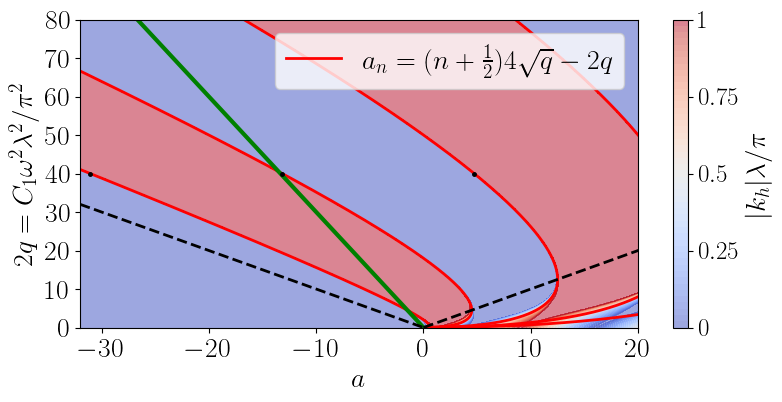

In [10]:
from scipy.ndimage import gaussian_filter

qtest = 20
pent = 3

with open('Map_rho_HQO.npy', 'rb') as f:
    aanum = np.load(f)
    qqnum = np.load(f)
    matrho1 = np.load(f)
    matrho2 = np.load(f)
    mats1 = np.load(f)
    mats2 = np.load(f)    

matrho = np.maximum(np.abs(matrho1), np.abs(matrho2))
realsmax = np.maximum(np.real(mats1), np.real(mats2))
#print(realsmax.shape)

mat_row = np.size(aanum)
mat_col = np.size(qqnum)    
    
aashape = aanum
qqshape = qqnum
aashape.shape=(1,mat_row)
qqshape.shape=(1,mat_col)

Mq = np.dot(np.transpose(aashape),np.ones((1,mat_col)))
Mp = np.dot(np.ones((mat_row,1)),qqshape)



# Set font size for plots
fonty = 20
levelou = np.linspace(0.01,(np.amax(np.asarray(realsmax))),100)
leveli = np.linspace(-0.00001,1+0.00001,50)

fig1 = plt.figure(1, figsize=(9, 4))
plt.rc('text', usetex=True)

#sc = plt.scatter(Mq, Mp, c=realsmax, cmap=plt.cm.coolwarm, s=marker_size, alpha=alphadata)
#sc = plt.contourf(Mq,2*Mp,realsmax, cmap=plt.cm.coolwarm,levels=levelou,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,realsmax, 100,cmap=plt.cm.coolwarm,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2))*(Mq+Mp)/2,100, cmap=plt.cm.coolwarm,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2)), cmap=plt.cm.coolwarm,levels=leveli,alpha=0.6)
sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2)), cmap=plt.cm.coolwarm,levels=leveli,alpha=0.5)


# Colorbar
cbar = plt.colorbar(sc, format='%.1f')

# Set colorbar label and font size
cbar.set_label(r'$|k_h|\lambda/\pi$', fontsize=fonty)  # Adjust font size as needed

# Define the tick locations and corresponding labels
tick_locations = [0, 0.25, 0.5, 0.75, 1]
tick_labels = [r'$0$', r'$0.25$', r'$0.5$', r'$0.75$', r'$1$']

# Set the ticks and labels
cbar.set_ticks(tick_locations)
cbar.set_ticklabels(tick_labels)

# Set tick parameters for font size
cbar.ax.tick_params(labelsize=fonty-2)  # Adjust font size as needed



# Fill stability regions with swapped axes
#plt.fill_betweenx(2*qq, -100 * np.ones(qq.size), A0e[0], facecolor='b', alpha=0.5)
#for i in range(1, len(A0e)):
#    plt.fill_betweenx(2*qq, A0o[i-1], A0e[i], facecolor='g' if i % 2 else 'b', alpha=0.5)

qqnum = np.linspace(0, 40, 500)
plt.plot((0.5+0)*4*np.sqrt(qqnum)-2*qqnum,2*qqnum,'r',linewidth=2,label=r'$a_n=(n+\frac{1}{2})4\sqrt{q}-2q$')
plt.plot((0.5+1)*4*np.sqrt(qqnum)-2*qqnum,2*qqnum,'r',linewidth=2)
plt.plot((0.5+2)*4*np.sqrt(qqnum)-2*qqnum,2*qqnum,'r',linewidth=2)
plt.plot((0.5+3)*4*np.sqrt(qqnum)-2*qqnum,2*qqnum,'r',linewidth=2)
plt.plot((0.5+4)*4*np.sqrt(qqnum)-2*qqnum,2*qqnum,'r',linewidth=2)

plt.plot(aanum.flatten(), -aanum.flatten()*pent, 'g-',linewidth=3) 
#plt.plot([0.,0.],[0.,100.], 'k--',linewidth=2) 
plt.plot([-32.,0.],[32.,0.], 'k--',linewidth=2) 
plt.plot([0.,32.],[0.,32.], 'k--',linewidth=2)

plt.plot(-2*qtest+energiesana,np.ones(energiesana.size)*qtest*2, 'k.',markersize=5)
    
# Customize axes
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlabel(r'$a$', fontsize=fonty)  # x-axis: a
plt.ylabel(r'$2q=C_1\omega^2\lambda^2/\pi^2$', fontsize=fonty)  # y-axis: q
plt.xlim(-32, 20.)
plt.ylim(0.,80.)
#plt.grid()
plt.xscale('linear')
plt.yscale('linear')

# Add legend
plt.legend(fontsize=fonty, loc='upper right')

# Show and save the plot
fig1 = plt.gcf()
plt.show()

fig1.savefig('HQO_stability_chart_aq_negative.png', format='png', dpi=1000, bbox_inches='tight')

### Dispersion data along QHO pass-band edges

Solves for the QHO pass-band boundaries (`listq`) and computes Floquet exponents
(`fexp1`, `fexp2`) along the physical dispersion locus, loading `Test_freq.npy`.


In [11]:
imax = 3
listq = np.ones(imax)

for ii in range(imax):
    #print(ii)
    solutionq = solve_HQO(ii, -pent, [100])
    listq[ii] = solutionq[0]

print(listq)
xtol=1e-18
maxfev=10000
factor=0.2
sol = fsolve(equation_solve, [100], args=(1, -3), xtol=xtol, maxfev=maxfev,factor=factor)[0]  
print(sol)

aHQO = -2*np.array(sol)/pent
aHQObis = (1+0.5)*4*np.sqrt(sol)-2*sol
print(aHQO,aHQObis)

[ 2.25 20.25 56.25]
20.25
-13.5 -13.5


In [ ]:
imax = 3
listq = np.ones(imax)

for ii in range(imax):
    #print(ii)
    solutionq = solve_HQO(ii, -pent, [100])
    listq[ii] = solutionq[0]

aHQO = -2*np.array(listq)/pent

ncoarse = 100
nprec = 2000

qq1 = np.linspace(0.01, listq[0]-1e-1, ncoarse)
qq2 = np.linspace(qq1[-1], listq[0]+1e-1, nprec)
qq3 = np.linspace(qq2[-1], listq[1]-1e-5, ncoarse)
qq4 = np.linspace(qq3[-1], listq[1]+1e-5, nprec)
qq5 = np.linspace(qq4[-1], listq[2]-1e-9, ncoarse)
qq6 = np.linspace(qq5[-1], listq[2]+1e-9, nprec)

# Combine all regions
listQ = np.concatenate([qq1, qq2, qq3, qq4, qq5, qq6])
listA = -2*listQ/pent
listrho1 = np.ones(listA.size,dtype=complex)
listrho2 = np.ones(listA.size,dtype=complex)
fexp1 = np.ones(listA.size,dtype=complex)
fexp2 = np.ones(listA.size,dtype=complex)

y_1 = [1., 0.0]
y_2 = [0.0, 1.]
inc = -1
for AA in listA:
    inc = inc + 1
    qtest = listQ[inc]
    # The resolution of the ODE needs to be very accurate DOP853 and Radau seem to do a good job
    sol1 = solve_ivp(equation_lin_HQO, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                    t_eval=None,args=(AA, qtest))
    sol2 = solve_ivp(equation_lin_HQO, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                    t_eval=None,args=(AA, qtest))
    # Assembly of the monodromy matrix Phi
    mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , 
                         [ sol1.y[1,-1], sol2.y[1,-1] ] ])
    eigenValues, eigenVectors = scipy.linalg.eig(mat_phi)
    listrho1[inc]       = eigenValues[0]
    listrho2[inc]       = eigenValues[1]
    fexp1[inc] = np.log(eigenValues[0])/np.pi
    fexp2[inc] = np.log(eigenValues[1])/np.pi
    
#print(listabsrho1)
#print(listabsrho2)
with open('Test_freq.npy', 'wb') as f:
    np.save(f, listA)
    np.save(f, listQ)
    np.save(f, listrho1)
    np.save(f, listrho2)
    np.save(f, fexp1)
    np.save(f, fexp2)

### Floquet multiplier vs frequency

Plots $|\rho|$ vs $\omega$ to show the pass-band structure and the
quantized frequency sequence in the QHO narrow-pass-band limit.


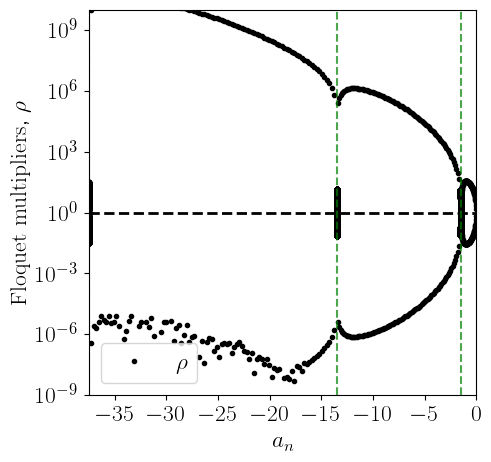

In [12]:
imax = 3
listq = np.ones(imax)

for ii in range(imax):
    #print(ii)
    solutionq = solve_HQO(ii, -pent, [100])
    listq[ii] = solutionq[0]

aHQO = -2*np.array(listq)/pent

with open('Test_freq.npy', 'rb') as f:
    listA = np.load(f)
    listQ = np.load(f)
    listrho1 = np.load(f)
    listrho2 = np.load(f)
    fexp1 = np.load(f)
    fexp2 = np.load(f)

fonty = 17
fig3 = plt.figure(3, figsize=(5, 5))
plt.rc('text', usetex=True)

plt.plot(listA, np.abs(listrho1), 'k.',label=r'$\rho$',linewidth=2.)
plt.plot(listA, np.abs(listrho2), 'k.',linewidth=2.)
plt.plot([np.min(listA),np.max(listA)],[1.,1.],'k--',linewidth=2.)
plt.axvline(x=aHQO[0], color='g', linestyle='--', alpha=0.7)
plt.axvline(x=aHQO[1], color='g', linestyle='--', alpha=0.7)
plt.axvline(x=aHQO[2], color='g', linestyle='--', alpha=0.7)
legend = plt.legend(fontsize=fonty,loc='lower left')
plt.xlabel(r'$a_n$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Floquet}$ $\mathrm{multipliers}$, $\rho$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#plt.xlim(xliminf-TT/2., xlimsup-TT/2.)   # set the ylim to ymin, ymax
plt.xlim(np.min(listA),0)   # set the ylim to ymin, ymax
plt.ylim(1e-9, 1e10)   # set the ylim to ymin, yma
plt.yscale('log')
fig3 = plt.gcf()
plt.show()


### → Figure 4a — QHO medium profile $F(x)$

Plots the piecewise-parabolic $F(x)$ over two periods, highlighting the
almost-everywhere-negative, QHO-shaped modulation. Produces `Modulation_negative_HQO.png`.


1 3


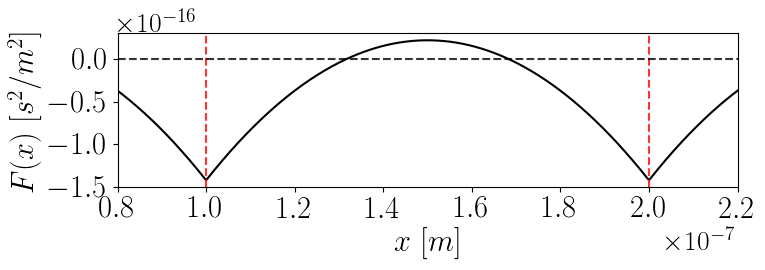

-1.4246823723041435e-16 2.225295989955157e-17
-12.804406601634037 2


In [13]:
# Define the base function over [0, pi]
def f_base(x, ala, qlq):
    return (ala+2*qlq-4*qlq*(x-np.pi/2)**2)

def f_base_physical(x, C0, C1, lamb):
    return (C0+C1)-2*C1*(np.pi/lamb)**2*(x-lamb/2)**2



#ymax = 1.05*np.max(np.pi*np.sqrt(aap)/np.sqrt(np.abs(s0))/lamb)
ymax = 6e16
eps0 = 8.854e-12
mu0 = 1.25663706127e-6
lamb = 1*100e-9
kmax = 2e8
vv = 299792458
#vv = vv + 15700000
aap = np.abs(listA)

alph2 = 1
bet2 = pent*alph2
s0 = -alph2*eps0*mu0

C0 = -1/vv**2
C1 = -3*C0

print(alph2,bet2)

xshift = lamb
xplot = np.array(np.linspace(-lamb*2,lamb*2,2000))+xshift
yplot = f_base_physical(xplot %lamb,C0,C1,lamb)


fonty = 22
fig1 = plt.figure(1, figsize=(8, 2))
plt.rc('text', usetex=True)

plt.plot(xplot,yplot,'k-')
plt.axvline(x=xshift, color='r', linestyle='--', alpha=0.8)
plt.axvline(x=lamb+xshift, color='r', linestyle='--', alpha=0.8)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.8)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$x$ $[m]$',fontsize=fonty)
plt.ylabel(r'$F(x)$ $[s^2/m^2]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(-lamb/5+xshift, lamb+lamb/5+xshift)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
#plt.ylim(-0.4e-9, 2e-11)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig1 = plt.gcf()
plt.show()

fig1.savefig('Modulation_negative_HQO.png', format='png', dpi=1000, bbox_inches='tight')

print(np.min(yplot),np.max(yplot))
print(-alph2+bet2*(1-np.pi**2/2),-alph2+bet2)

### Heavy computation — generates `Multi_FFT_HQO.npy`

Time-integrates the QHO Mathieu ODE for many frequencies and computes Bloch-wave FFTs.
**This is the long-running step** (the 6.6 GB output file is not stored in the repository).
Run this cell to regenerate `Multi_FFT_HQO.npy` before running the Figure 4c cells below.


In [ ]:
y_1 = [1., 0.0]
y_2 = [0.0, 1.]
y0 = np.array([0.1,-0.2])

omegas = {}  # To store computed omega values
fft_results = {}  # To store FFT results for plotting
q_results = {}

lamb = 1e-7

nT = int(2**13)
nTvisu = 1
nprimary = 3000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]
x_extended = np.linspace(0.,np.pi*nT-dt,nT*nprimary)  # Extended domain
L = np.max(x_extended*lamb/np.pi)
phi = np.linspace(-np.pi/2, np.pi/2, nprimary)

pent = 3
alph2 = 1
bet2 = pent*alph2
lamb = 1e-7
kmax = 2e8
eps0 = 8.854e-12
mu0 = 1.25663706127e-6
vv = 1/np.sqrt(eps0*mu0)
s0 = -alph2*eps0*mu0
s1=bet2*eps0*mu0

omega = (vv*2*np.pi*np.sqrt(2)/lamb)*(pent/(pent-1)/np.sqrt(bet2))

nlist = np.linspace(0,2,3)
print(nlist)
lqtest = np.zeros((nlist.size,1))
eigenvectors = np.zeros((nlist.size,phi.size))

inc = -1
for nn in nlist:
    inc = inc + 1
    lqtest[inc] = (omega*(inc+0.5))**2*lamb**2*s1/np.pi**2/2
    qtest = lqtest[inc]
    p_monic = sp.hermite(nn.astype(int), monic=True)
    chi = np.sqrt(2)*(qtest)**0.25*phi
    eigenvectors[inc,:] = p_monic(chi)*np.exp(-np.sqrt(qtest)*phi**2)*((2*np.sqrt(qtest)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))

lmaxou = np.zeros(nlist.size)  
enermean = np.zeros(nlist.size)
qadim0 = np.zeros(nlist.size)
intou = np.zeros(nlist.size)

A01 = 1
lA0 = np.array([A01,A01,A01])*np.linspace(1,3,3)**(1/6)

ltheta = np.array([np.pi/8,3*np.pi/8,5*np.pi/8,7*np.pi/8])
coeff = (1+0.5j)

inctot = -1
inc = -1
for ii in range(len(nlist)):
    inc = inc + 1
    omegana = omega*(0.5+inc)
    incou = -1
    for theta in ltheta:
        incou = incou + 1
        inctot = inctot + 1
        omegas[inctot] = omegana
        rho       = np.cos(theta) + 1j*np.sin(theta) 
        OptiFloq = np.zeros((nT,nprimary),dtype=complex)
        
        for jj in range(nT):
            OptiFloq[jj,:] = coeff*eigenvectors[inc,:]*rho**jj #We can try some complex constant
            
        qopti = np.real(OptiFloq.reshape((int(nT*nprimary),)))
        wave = np.real(qopti)
        N_wave = len(wave)
        fft_wave = np.fft.fft(wave)
        fft_wave = fft_wave / N_wave  # Normalize the amplitude
        # Compute the wavenumbers
        k1 = 2 * np.pi * np.fft.fftfreq(N_wave, d=L / N_wave)  # Wavenumbers
        k1 = np.fft.fftshift(k1)                      # Shift wavenumbers
        # Shift the FFT for symmetry
        fft_wave_shifted = np.fft.fftshift(fft_wave)
            
        peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k1, height=1e-6, distance=1)
        maxou = np.max(peak_amplitudes)
        print(maxou)
        fftadim =  lA0[inc]*np.abs(fft_wave_shifted)/maxou
        qadim = lA0[inc]*np.real(qopti)/maxou
        energy2 = eps0*sum(abs(fftadim)**2)
        energy = eps0*np.trapz(np.abs(qadim)**2, x_extended*lamb/np.pi) / (lamb*nT)
        print(energy2,energy)
        
        q_results[inctot] = np.real(qadim)  # Store the wave solution for each configuration
        peak_waveadim, peak_ampadim = find_fft_peaks(fftadim, k1, height=0.01, distance=1)
        fft_results[inctot] = {
        'k': k1, 'fft': fftadim, 'peaks': (peak_waveadim, peak_ampadim)
    }

with open('Multi_FFT_HQO.npy', 'wb') as f:
    np.save(f, omegas)
    np.save(f, q_results)
    np.save(f, fft_results)
    np.save(f, ltheta)

### → Figure 4c — Bloch wave FFT profiles for modes 0, 1, 2

Loads `Multi_FFT_HQO.npy` (generated by the cell above) and plots the
spatial FFT of each Bloch mode. Produces `Mutli_phi_FFT_mode0/1/2_HQO.png`.
**Requires `Multi_FFT_HQO.npy` — run the heavy-computation cell first.**


(0.9238795325112867+0.3826834323650898j)
(0.38268343236508984+0.9238795325112867j)
(-0.3826834323650897+0.9238795325112867j)
(-0.9238795325112867+0.3826834323650899j)


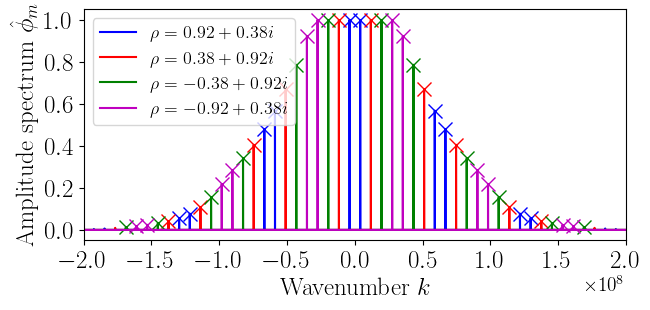

(0.9238795325112867+0.3826834323650898j)
(0.38268343236508984+0.9238795325112867j)
(-0.3826834323650897+0.9238795325112867j)
(-0.9238795325112867+0.3826834323650899j)


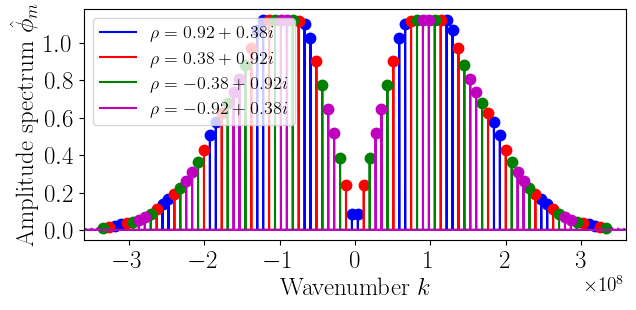

(0.9238795325112867+0.3826834323650898j)
(0.38268343236508984+0.9238795325112867j)
(-0.3826834323650897+0.9238795325112867j)
(-0.9238795325112867+0.3826834323650899j)


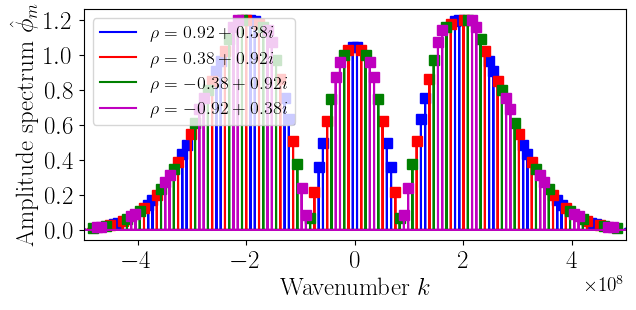

In [14]:
with open('Multi_FFT_HQO.npy', 'rb') as f:
    omegas = np.load(f,allow_pickle=True)
    q_results = np.load(f,allow_pickle=True)
    fft_results = np.load(f,allow_pickle=True)
    ltheta = np.load(f,allow_pickle=True)
    
fft_results = fft_results.item()  # Convert NumPy object array to a dictionary
q_results = q_results.item()  # Convert NumPy object array to a dictionary
#maxou = np.max(np.concatenate([fft_results[0]['fft'],fft_results[1]['fft'],fft_results[2]['fft'],fft_results[3]['fft']]))
maxou = 1
colors = ['b', 'r', 'g', 'm']  
laboul = [r'$\rho=0.92+0.38i$', r'$\rho=0.38+0.92i$', r'$\rho=-0.38+0.92i$', r'$\rho=-0.92+0.38i$']  # Since it's a set, duplicate values will be removed


fonty = 18 
fig1 = plt.figure(1, figsize=(7, 3))
incai = -1
for theta in ltheta:
    incai = incai + 1
    rho       = np.cos(theta) + 1j*np.sin(theta)
    print(rho)
    fft_res = fft_results[incai]
    plt.plot(fft_res['k'], fft_res['fft']/maxou, f'{colors[incai]}-', label=laboul[incai])
    plt.plot(fft_res['peaks'][0], fft_res['peaks'][1]/maxou, f'x{colors[incai]}', markersize=10)
    #plt.plot((listcell-lamb)*1.42e16, qcell**2/5e11)

    
# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-4)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-kmax, kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
# Add legend
plt.legend(fontsize=fonty-5, loc='upper left')
plt.show()


fig1.savefig('Mutli_phi_FFT_mode0_HQO.png', format='png', dpi=1000, bbox_inches='tight')



#maxou = np.max(np.concatenate([fft_results[4]['fft'],fft_results[5]['fft'],fft_results[6]['fft'],fft_results[7]['fft']]))

fonty = 18 
fig2 = plt.figure(2, figsize=(7, 3))
incai = 3
for theta in ltheta:
    incai = incai + 1
    rho       = np.cos(theta) + 1j*np.sin(theta)
    print(rho)
    fft_res = fft_results[incai]
    plt.plot(fft_res['k'], fft_res['fft']/maxou, f'{colors[incai-4]}-', label=laboul[incai-4])
    plt.plot(fft_res['peaks'][0], fft_res['peaks'][1]/maxou, f'.{colors[incai-4]}', markersize=15)
    #plt.plot((listcell-lamb)*1.42e16, qcell**2/5e11)

    
# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-4)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-1.8*kmax, 1.8*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
# Add legend
plt.legend(fontsize=fonty-5, loc='upper left')
plt.show()


fig2.savefig('Mutli_phi_FFT_mode1_HQO.png', format='png', dpi=1000, bbox_inches='tight')





#maxou = np.max(np.concatenate([fft_results[8]['fft'],fft_results[9]['fft'],fft_results[10]['fft'],fft_results[11]['fft']]))

fonty = 18 
fig3 = plt.figure(3, figsize=(7, 3))
incai = 7
for theta in ltheta:
    incai = incai + 1
    rho       = np.cos(theta) + 1j*np.sin(theta)
    print(rho)
    fft_res = fft_results[incai]
    plt.plot(fft_res['k'], fft_res['fft']/maxou, f'{colors[incai-8]}-', label=laboul[incai-8])
    plt.plot(fft_res['peaks'][0], fft_res['peaks'][1]/maxou, f's{colors[incai-8]}', markersize=7)
    #plt.plot((listcell-lamb)*1.42e16, qcell**2/5e11)

    
# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-4)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-2.5*kmax, 2.5*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
# Add legend
plt.legend(fontsize=fonty-5, loc='upper left')
plt.show()


fig3.savefig('Mutli_phi_FFT_mode2_HQO.png', format='png', dpi=1000, bbox_inches='tight')





### Energy computation from precomputed aggregated results

Loads `Final_aggregated_results_nT15_nprimary5000.npz` and
`Test_final_triplet_...npy` to compute grouped electromagnetic energies per mode.


In [15]:
from numpy.fft import fft


nT = int(2**13)
nTvisu = 1
nprimary = 3000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]
x_extended = np.linspace(0.,np.pi*nT-dt,nT*nprimary)  # Extended domain

N_wave= int(2**19)
#N_wave= int(2**18)
LL = 1.e-4
x_energy = np.linspace(0.,LL,N_wave)  # Extended domain
dL = x_energy[1]-x_energy[0]

eps0 = 8.854e-12

energies_grouped = []

#        energy2 = eps0*sum(abs(fftadim)**2)*((lamb*nT)/N_wave) / N_wave / (lamb*nT)
#        energy = eps0*np.trapz(np.abs(qadim)**2, x_extended*lamb/np.pi) / (lamb*nT)


for group_start in [0, 4, 8]:
    group_energies = []
    for i in range(group_start, group_start + 4):
        #EE_mod = np.interp(x_energy, x_extended, q_results[i])
        EE_mod = q_results[i]
        #energy = eps0*sum(abs(EE_mod)**2)*dL / LL
        #tuta = np.fft.fft(np.real(EE_mod))
        #tuta_shifted = np.fft.fftshift(tuta)
        #k1 = 2 * np.pi * np.fft.fftfreq(len(EE_mod), d=LL / len(EE_mod))
        #k1 = np.fft.fftshift(k1)
        #peak_wavenumbers, peak_amplitudes = find_fft_peaks(np.abs(tuta_shifted), k1, height=1e-6, distance=1)
        #maxou = np.max(peak_amplitudes)
        #print(maxou)
        #tuta_shifted = tuta_shifted/maxou
        #if i == 0:
        #    plt.plot(k1,np.abs(tuta_shifted))
        #    plt.xlim(-kmax, kmax)   # set the ylim to ymin, ymax
        tuta_shifted = fft_results[i]['fft']
        kk1 = fft_results[i]['k']
        energy2 = eps0*sum(abs(tuta_shifted)**2)
        #energy2 = eps0*sum(abs(tuta_shifted)**2) / (len(EE_mod)**2)
        #energy2 = eps0*sum(abs(tuta_shifted)**2)*(LL/len(x_energy)) / LL / len(x_energy) # No not the same
        
        #EE_mod = EE_mod/maxou
        energy = eps0*np.trapz(np.abs(EE_mod)**2, x_extended*lamb/np.pi) / (lamb*nT)
        #energy = eps0*np.trapz(np.abs(EE_mod)**2, x_energy) / LL #No not the same
        print(energy2)
        group_energies.append(energy)
    energies_grouped.append(group_energies)
    print(f"Group {group_start//4}: ", *group_energies)

# Compute mean and std for each group
for i, group in enumerate(energies_grouped):
    aa = np.mean(group)
    bb = np.std(group)
    print(f"Group {i} mean: {aa}, std: {bb}")

2.7680156885610665e-11
2.8793712032238798e-11
3.116366676977573e-11
3.510804853512973e-11
Group 0:  2.7680156881823422e-11 2.8793712029230416e-11 3.116366676786344e-11 3.510804853184013e-11
9.427114070968675e-11
8.747449685381157e-11
8.309106620492884e-11
8.09163045086364e-11
Group 1:  9.427114070968655e-11 8.747449685381222e-11 8.309106620492831e-11 8.091630450863027e-11
1.3353392360373338e-10
1.3488667297741306e-10
1.3891018375452318e-10
1.456593785815668e-10
Group 2:  1.3353392360373405e-10 1.3488667297741324e-10 1.389101837545233e-10 1.456593785815676e-10
Group 0 mean: 3.068639605268935e-11, std: 2.8459850995326903e-12
Group 1 mean: 8.643825206926433e-11, std: 5.102046299759572e-12
Group 2 mean: 1.3824753972930955e-10, std: 4.714023084884104e-12


In [16]:
with open('Multi_FFT_HQO.npy', 'rb') as f:
    omegas = np.load(f,allow_pickle=True)
    q_results = np.load(f,allow_pickle=True)
    fft_results = np.load(f,allow_pickle=True)
    ltheta = np.load(f,allow_pickle=True)

### → Figure 4a — Dispersion relation in the extended Brillouin zone

Plots $\omega$ vs $k$ showing the collapse of pass-band branches onto
the quantized QHO levels $\omega_n = (n+\tfrac{1}{2})\omega_0$.
Produces `Dispersion_relation_HQO.png`.


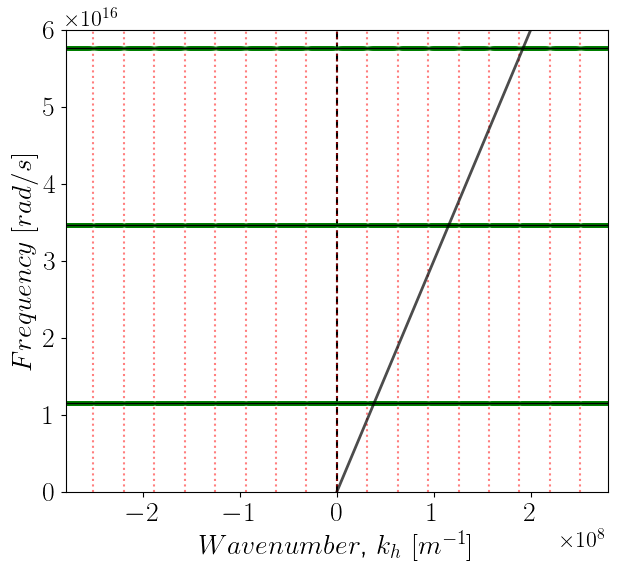

In [17]:
omegas = omegas.item()  # Convert NumPy object array to a dictionary


shift_range = np.arange(-20, 20)  # Shifts from -3 to 3, including 0
# Generalized concatenation
eigtot1ext = np.concatenate([np.imag(fexp1) + k*2 for k in shift_range])
eigtot2ext = np.concatenate([np.imag(fexp2) + k*2 for k in shift_range])
aaext = np.tile(aap, len(shift_range))  # Use len() instead of np.length()

toto1 = np.where(np.abs(np.real(fexp1))<1e-3)
fexp1sort = fexp1[toto1]
aasort1 = aap[toto1]
toto2 = np.where(np.abs(np.real(fexp2))<1e-3)
fexp2sort = fexp2[toto2]
aasort2 = aap[toto2]
aaextsort1 = np.tile(aasort1, len(shift_range))  # Use len() instead of np.length()
aaextsort2 = np.tile(aasort2, len(shift_range))  # Use len() instead of np.length()

eigtot1extsort = np.concatenate([np.imag(fexp1sort) + k*2 for k in shift_range])
eigtot2extsort = np.concatenate([np.imag(fexp2sort) + k*2 for k in shift_range])


# Define the filter ranges
A, B = -np.pi / lamb, np.pi / lamb  # Example values for the x-axis range
C, D = 1e16, 1.5e16   # Example values for the y-axis range

# Create a mask that satisfies both conditions
mask = (np.pi*eigtot1extsort/lamb >= A) & (np.pi*eigtot1extsort/lamb <= B) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb <= D)
mask2 = (np.pi*eigtot2extsort/lamb >= A) & (np.pi*eigtot2extsort/lamb <= B) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb <= D)


# Apply the mask to filter the data
Afiltered_eigtot1extsort = eigtot1extsort[mask]
Afiltered_aaextsort1 = aaextsort1[mask]
Afiltered_eigtot2extsort = eigtot2extsort[mask2]
Afiltered_aaextsort2 = aaextsort2[mask2]


# Define the filter ranges
A, B = -2*np.pi / lamb, -np.pi / lamb  # Example values for the x-axis range
C, D = 3e16, 4e16   # Example values for the y-axis range
E, F = np.pi / lamb, 2*np.pi / lamb  # Example values for the x-axis range

# Create a mask that satisfies both conditions
mask = (np.pi*eigtot1extsort/lamb >= A) & (np.pi*eigtot1extsort/lamb <= B) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb <= D)
mask2 = (np.pi*eigtot2extsort/lamb >= A) & (np.pi*eigtot2extsort/lamb <= B) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb <= D)
mask3 = (np.pi*eigtot1extsort/lamb >= E) & (np.pi*eigtot1extsort/lamb <= F) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb <= D)
mask4 = (np.pi*eigtot2extsort/lamb >= E) & (np.pi*eigtot2extsort/lamb <= F) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb <= D)


Bfiltered_eigtot1extsort = eigtot1extsort[mask]
Bfiltered_aaextsort1 = aaextsort1[mask]
Bfiltered_eigtot2extsort = eigtot2extsort[mask2]
Bfiltered_aaextsort2 = aaextsort2[mask2]

Cfiltered_eigtot1extsort = eigtot1extsort[mask3]
Cfiltered_aaextsort1 = aaextsort1[mask3]
Cfiltered_eigtot2extsort = eigtot2extsort[mask4]
Cfiltered_aaextsort2 = aaextsort2[mask4]




# Define the filter ranges
A, B = -3*np.pi / lamb, -2*np.pi / lamb  # Example values for the x-axis range
C, D = 5e16, 6e16   # Example values for the y-axis range
E, F = 2*np.pi / lamb, 3*np.pi / lamb  # Example values for the x-axis range

# Create a mask that satisfies both conditions
mask = (np.pi*eigtot1extsort/lamb >= A) & (np.pi*eigtot1extsort/lamb <= B) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb <= D)
mask2 = (np.pi*eigtot2extsort/lamb >= A) & (np.pi*eigtot2extsort/lamb <= B) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb <= D)
mask3 = (np.pi*eigtot1extsort/lamb >= E) & (np.pi*eigtot1extsort/lamb <= F) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb <= D)
mask4 = (np.pi*eigtot2extsort/lamb >= E) & (np.pi*eigtot2extsort/lamb <= F) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb <= D)


Dfiltered_eigtot1extsort = eigtot1extsort[mask]
Dfiltered_aaextsort1 = aaextsort1[mask]
Dfiltered_eigtot2extsort = eigtot2extsort[mask2]
Dfiltered_aaextsort2 = aaextsort2[mask2]

Efiltered_eigtot1extsort = eigtot1extsort[mask3]
Efiltered_aaextsort1 = aaextsort1[mask3]
Efiltered_eigtot2extsort = eigtot2extsort[mask4]
Efiltered_aaextsort2 = aaextsort2[mask4]






lamb = 1e-7
pent = 3
alph2 = 1
bet2 = pent*alph2
lamb = 1e-7
kmax = 2e8
eps0 = 8.854e-12
mu0 = 1.25663706127e-6
cc = 1/np.sqrt(eps0*mu0)
omegat = cc*2*np.pi*np.sqrt(2)*pent/(np.sqrt(alph2*pent)*lamb*(pent-1))











ymax = 1.05*np.max(np.pi*np.sqrt(aap)/np.sqrt(np.abs(s0))/lamb)
ymax = 6e16
fonty = 20
fig3 = plt.figure(3, figsize=(7, 6))
plt.rc('text', usetex=True)

plt.axvline(x=0, color='k', linestyle='--', alpha=1)
# Add vertical dashed lines
for i in range(-50,50):
    x_pos = i * np.pi / lamb
    plt.axvline(x=x_pos, color='r', linestyle=':', alpha=0.5)

plt.plot(np.pi*eigtot1extsort/lamb, np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.,markersize=5, alpha=0.3)
plt.plot(np.pi*eigtot2extsort/lamb, np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.,markersize=5, alpha=0.3)
#plt.plot(np.pi*Afiltered_eigtot1extsort/lamb, np.pi*np.sqrt(Afiltered_aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Afiltered_eigtot2extsort/lamb, np.pi*np.sqrt(Afiltered_aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Bfiltered_eigtot1extsort/lamb, np.pi*np.sqrt(Bfiltered_aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Bfiltered_eigtot2extsort/lamb, np.pi*np.sqrt(Bfiltered_aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Cfiltered_eigtot1extsort/lamb, np.pi*np.sqrt(Cfiltered_aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Cfiltered_eigtot2extsort/lamb, np.pi*np.sqrt(Cfiltered_aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Dfiltered_eigtot1extsort/lamb, np.pi*np.sqrt(Dfiltered_aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Dfiltered_eigtot2extsort/lamb, np.pi*np.sqrt(Dfiltered_aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Efiltered_eigtot1extsort/lamb, np.pi*np.sqrt(Efiltered_aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Efiltered_eigtot2extsort/lamb, np.pi*np.sqrt(Efiltered_aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*eigtot2extsort/lamb, np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.)
plt.plot([0,kmax], [0,vv*kmax], 'k-',linewidth=2.,alpha=0.7)
#plt.plot(fft_results[9]['peaks'][0], omegas[9]*np.ones(fft_results[9]['peaks'][0].size),'sr',markersize=8)
#plt.plot(fft_results[5]['peaks'][0], omegas[5]*np.ones(fft_results[5]['peaks'][0].size),'.r',markersize=18)
#plt.plot(fft_results[1]['peaks'][0], omegas[1]*np.ones(fft_results[1]['peaks'][0].size),'xr',markersize=12)
plt.plot([-1.4*kmax,1.4*kmax], [(0+0.5)*omegat,(0+0.5)*omegat], 'k-',linewidth=1.,alpha=1)
plt.plot([-1.4*kmax,1.4*kmax], [(1+0.5)*omegat,(1+0.5)*omegat], 'k-',linewidth=1.,alpha=1)
plt.plot([-1.4*kmax,1.4*kmax], [(2+0.5)*omegat,(2+0.5)*omegat], 'k-',linewidth=1.,alpha=1)
#legend = plt.legend(fontsize=fonty,loc='right')
plt.xlabel(r'$Wavenumber$, $k_h$ $[m^{-1}]$',fontsize=fonty)
plt.ylabel(r'$Frequency$ $[rad/s]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-4)
ax.yaxis.get_offset_text().set_fontsize(fonty-4)

plt.xlim(-1.4*kmax, 1.4*kmax)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig3 = plt.gcf()
plt.show()

fig3.savefig('Dispersion_relation_HQO.png', format='png', dpi=1000, bbox_inches='tight')

## By Arnaud Lazarus - 06/13/2026